In [1]:
# @title imports 
%load_ext autoreload
%autoreload 2
import os
import pickle
from typing import Set
# from jedi import settings
import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse import data 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# import umap.plot as uplot
import sys  

sys.path.append('C:/Users/Nishant Joshi/Downloads/Old_code/repo/single_cell_analysis/scripts')
from utils import *
sys.path.append(os.getcwd()+'/../scripts/')
from UMAP_utils import *
from plot_utils import *
sys.path.append('C:/Users/Nishant Joshi/Model_fitting/GIFFittingToolbox/src/examples/')
from cluster_stability import *
from neuromod_utils import * 
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score 

In [2]:
savepath = 'G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/'
# savepath2 = 'G:/My Drive/Data For Publication/paper2/PNAS_revision/'

In [3]:
discarded_exps = ['xuan_151118_E1',
                  'xuan_15319_E1',
                  'xuan_20919_E2',
                  'xuan_27919_E1',
                  'xuan_27919_E2',
                  'xuan_27919_E3',
                  'NC_20717_E5' ,
                  'NC_25717_E2',
                  'payam_31019_E5',
                  'payam_101019_E5',
                  'NC_24717_E1',
                  'xuan_27319_E4',
                  'xuan_23119_E2',
                  'xuan_3419_E2',
                  'xuan_22319_E1',
                  'xuan_19319_E4',
                  'xuan_22319_E4',
                  'xuan_26319_E4']

In [4]:
# %matplotlib widget

ephys = pd.read_pickle("G:/My Drive/Data For Publication/FN_analysed_feat_set/Ephys_collection_all_exps_all_conds_spikes_calculated_5ms.pkl")
ephys_with_mi = pd.read_pickle("G:/My Drive/Data For Publication/FN_analysed_feat_set/Ephys_collection_all_exps_all_conds_spikes_calculated_5ms_with_MI.pkl")

# ephys = ephys[~ephys.exp_name.isin(discarded_exps)]
ephys_with_mi = ephys_with_mi[~ephys_with_mi.exp_name.isin(discarded_exps)]



data_ephys_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][ephys.columns[1:]]
data_ephys_FN_acsf = data_ephys_FN_acsf[data_ephys_FN_acsf.trialnr==0]

data_wave_FN_acsf = ephys[ephys.cond.isin(['acsf','acsf_bic'])][['waveform','tau', 'exp_name', 'cond', 'trialnr']]
data_wave_FN_acsf=data_wave_FN_acsf[data_wave_FN_acsf.trialnr==0]
# data_wave_FN_acsf.drop_duplicates('exp_name')

# exps_with_double_trials = np.array(data_wave_FN_acsf.exp_name)[list(np.where(np.unique(data_wave_FN_acsf.exp_name,return_counts=True)[1]>1)[0])]
# data_wave_FN_acsf = data_wave_FN_acsf[data_wave_FN_acsf.trialnr==0]



In [5]:
ephys 

,waveform,current_at_first_spike,ap_count,fr,inst_fr,time_to_first_spike,mean_isi,median_isi,max_isi,min_isi,...,mean_amplitude,median_amplitude,min_amplitude,max_amplitude,tau,exp_name,cond,trialnr,ei_labels,FI
0,"[-54.54378329877612, -54.46670967949024, -54.3...",208.833286,3002,8.675000,0.029865,172.35,119.895285,50.75,1586.15,6.65,...,96.479430,96.687501,59.500001,142.781250,50,asli_18719_E2,acsf,0,0.0,0.563102
1,"[-55.98218202977632, -55.906672598467324, -55....",227.268867,2736,8.061111,0.027074,172.35,131.556289,57.85,1586.05,6.50,...,97.279731,97.593749,60.218751,142.468747,50,asli_18719_E2,m1-ago,1,0.0,0.537862
2,"[-57.60735370960563, -57.5371207682914, -57.46...",234.895342,2752,8.327778,0.024940,172.35,130.791203,63.05,1585.95,6.80,...,98.001476,98.093750,64.062499,142.500002,50,asli_18719_E2,m1-ant,2,0.0,0.549823
3,"[-45.17339291317122, -45.16017843570028, -45.1...",267.928454,175,0.523333,0.006817,8310.95,2011.697126,1098.90,15342.55,15.50,...,101.357143,100.218751,66.343751,130.593747,250,asli_11719_E1,acsf,0,1.0,0.169306
4,"[-38.0694195229028, -38.01049117797187, -37.91...",154.528642,140,0.413333,0.007331,8315.00,2513.425180,1389.10,17332.95,12.25,...,103.810268,102.187501,52.999999,141.406246,250,asli_11719_E1,m1-ago,1,1.0,0.13403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848,"[-61.10945982877752, -61.065825223659814, -61....",161.497284,1842,5.119444,0.027284,172.35,195.444758,90.05,1833.55,4.30,...,127.369503,128.296874,90.000000,155.343749,50,xuan_9919_E3,cirazoline,1,0.0,0.407006
849,"[-59.1405467001866, -59.05404121131825, -58.97...",95.888455,798,2.216667,0.014901,172.35,451.456211,263.15,3309.75,7.05,...,121.712602,122.359375,90.843752,153.343752,50,xuan_9919_E3,m1-ago+ant,2,0.0,0.213848
850,"[-55.433499918035345, -55.42865182811217, -55....",302.800529,4164,11.594444,0.045283,168.40,86.431059,35.00,1207.90,4.05,...,103.440247,103.921875,68.250000,158.000004,50,xuan_9919_E4,acsf,0,0.0,0.606711
851,"[-56.59849642434493, -56.58639136936646, -56.5...",319.120484,5491,15.261111,0.053128,168.40,65.539836,25.30,1038.15,4.25,...,101.335333,101.500001,61.437500,157.593746,50,xuan_9919_E4,cirazoline,1,0.0,0.68117


In [6]:
acsf_temp, drug_temp = return_acsf_and_drug(ephys,cond=['d1'],joint=False,remove_duplicates=True,sample=None)

In [7]:
drug_temp[drug_temp.trialnr==2].exp_name

121     NC_30617_E4
171     NC_21817_E3
177     NC_30817_E1
180     NC_30817_E3
188     NC_13917_E2
192     NC_14917_E1
200     NC_61017_E7
211    NC_101017_E4
215    NC_101017_E5
370    NC_221217_E2
373    NC_221217_E3
392      NC_4717_E2
Name: exp_name, dtype: object

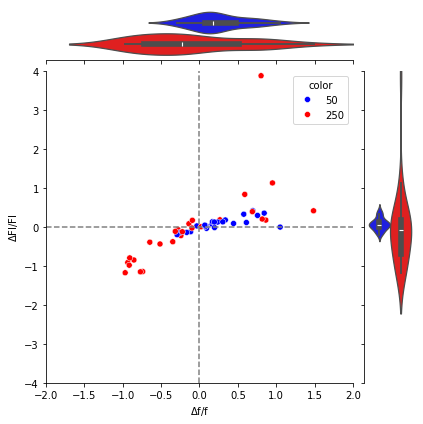

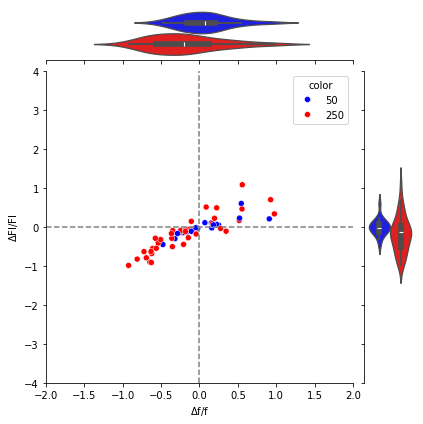

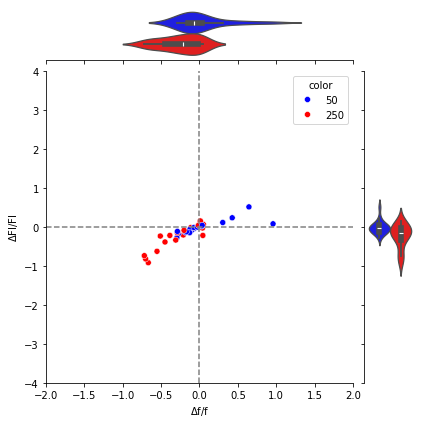

In [8]:
def plot_FI_vs_FR_input_based(data_acsf,data_drug,ax=None, plot=True, c = 'blue',x_lim = None, y_lim = None, save=False, savepath = None):
    ind_na = np.array(data_drug['FI'].isna())
    c_labels = []
    data_acsf = data_acsf[~ind_na]
    data_drug = data_drug[~ind_na]

    for i in data_acsf.tau:
        if i==250:
            c_labels.append('250')
        else:
            c_labels.append('50')

    c = c_labels
    delta_fi = (np.array(data_drug['FI']) - np.array(data_acsf['FI']))/np.array(data_acsf['FI'])
    delta_fr = (np.array(data_drug['fr']) - np.array(data_acsf['fr']))/np.array(data_acsf['fr'])
    df_temp = pd.DataFrame({'$\Delta$f/f':np.float32(delta_fr),
                                '$\Delta$FI/FI':np.float32(delta_fi),
                                'color':c})

    df_temp = df_temp[(df_temp['$\Delta$FI/FI']>=y_lim[0]) &(df_temp['$\Delta$FI/FI']<=y_lim[1])]
    df_temp = df_temp[(df_temp['$\Delta$f/f']>=x_lim[0]) &(df_temp['$\Delta$f/f']<=x_lim[1])]

    if plot:
        if ax is None:

            g = sns.JointGrid(data=df_temp, x="$\Delta$f/f", y="$\Delta$FI/FI",hue='color',palette=['blue','red'])
            g.plot(sns.scatterplot, sns.violinplot)
            g.ax_joint.axhline(y=0, color='gray', linestyle='--')  # Horizontal line at y=16
            g.ax_joint.axvline(x=0, color='gray', linestyle='--')  # Horizontal line at y=16

            if x_lim !=None and y_lim !=None: 
                g.ax_joint.set_xlim(x_lim)
                g.ax_joint.set_ylim(y_lim)
            # plt.legend(['inh','exc'])

            plt.xlabel('$\Delta$fr/fr')
            plt.ylabel('$\Delta$FI/FI')

            if save:
                plt.savefig(savepath,dpi=200)
            plt.show()
        else:
            ax.scatter(delta_fr[~ind_na], delta_fi[~ind_na],c=c) 

    return df_temp

for cond in ['d1','d2','m1-ago']:
    # cond  = 'm1-ago'
    data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=[cond],joint=False)
    plot_FI_vs_FR_input_based(data_acsf,data_drug,x_lim=[-2,2],y_lim=[-4,4],save=True,
                            savepath=savepath+cond+'.pdf')
    # plot_FI_vs_FR(data_acsf,data_drug,save=False,savepath=savepath2+cond+'.pdf')



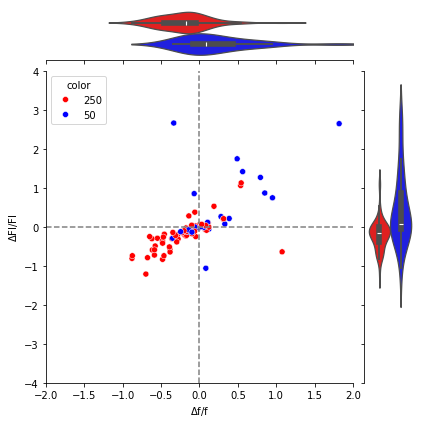

In [9]:
repeated_acsf = ephys[ephys.cond=='acsf']
idx = np.where(np.unique(repeated_acsf.exp_name,return_counts=True)[1]>1)[0]
names = np.unique(repeated_acsf.exp_name,return_counts=True)[0][idx]

acsf_with_2_trials = list(set(np.array(repeated_acsf.exp_name)[idx]))
repeated_acsf_filtered = repeated_acsf[repeated_acsf.exp_name.isin(names)]
exps,counts = np.unique(repeated_acsf_filtered.exp_name,return_counts=True)
delta_FI = []
delta_fr = []
ei = []
for exp in exps:
    df = repeated_acsf_filtered[repeated_acsf_filtered.exp_name==exp]
    if np.array(df.tau)[0] ==250:
        ei.append('250')
    else:
        ei.append('50')

    FI1 = df[df.trialnr == 0 ]['FI']
    FI2 = df[df.trialnr == 1 ]['FI']
    delta_FI.append((FI2.to_numpy()-FI1.to_numpy())/FI1.to_numpy())

    Fr1 = df[df.trialnr == 0 ]['fr']
    Fr2 = df[df.trialnr == 1 ]['fr']
    delta_fr.append((Fr2.to_numpy()-Fr1.to_numpy())/Fr1.to_numpy())


data_frame  = pd.DataFrame({'$\Delta$f/f'   :np.float32(np.hstack(delta_fr)),
                            '$\Delta$FI/FI' :np.float32(np.hstack(delta_FI)),
                            'color':ei})
ylim = [-4,4]
xlim = [-2,2]
data_frame = data_frame[(data_frame['$\Delta$FI/FI']<=ylim[1]) & (data_frame['$\Delta$FI/FI']>ylim[0])]
data_frame = data_frame[(data_frame['$\Delta$f/f']<=xlim[1]) & (data_frame['$\Delta$f/f']>xlim[0])]


g = sns.JointGrid(data=data_frame, x="$\Delta$f/f", y="$\Delta$FI/FI",hue='color',palette=['red','blue'])
g.plot(sns.scatterplot, sns.violinplot)
g.ax_joint.axhline(y=0, color='gray', linestyle='--')  # Horizontal line at y=16
g.ax_joint.axvline(x=0, color='gray', linestyle='--')  # Horizontal line at y=16
g.ax_joint.set_xlim(xlim)
g.ax_joint.set_ylim(ylim)
plt.savefig(savepath+'acsf'+'.pdf',dpi=200)
plt.show()

In [11]:
data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=['d1'],joint=False)
d1_diff =  plot_FI_vs_FR_input_based(data_acsf,data_drug,plot=False, x_lim=[-2,2],y_lim=[-4,2],save=False,savepath=savepath+cond+'.pdf')
data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=['d2'],joint=False)
d2_diff =  plot_FI_vs_FR_input_based(data_acsf,data_drug,plot=False, x_lim=[-2,2],y_lim=[-4,2],save=False,savepath=savepath+cond+'.pdf')
data_acsf,data_drug  = return_acsf_and_drug(ephys,cond=['m1-ago'],joint=False)
m1_diff =  plot_FI_vs_FR_input_based(data_acsf,data_drug,plot=False, x_lim=[-2,2],y_lim=[-4,2],save=False,savepath=savepath+cond+'.pdf')


### Cell-type difference in FI

In [12]:
from scipy import stats
inh_data = d1_diff[d1_diff.color=='50']
exc_data = d1_diff[d1_diff.color=='250']
print('D1')
print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))

inh_data = d2_diff[d2_diff.color=='50']
exc_data = d2_diff[d2_diff.color=='250']
print('D2')
print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))


inh_data = m1_diff[m1_diff.color=='50']
exc_data = m1_diff[m1_diff.color=='250']
print('M1')
print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))


print('acsf-acsf')
inh_data = data_frame[data_frame.color=='50']
exc_data = data_frame[data_frame.color=='250']

print(stats.ttest_ind(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32), inh_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)))
# exc_data['$\Delta$FI/FI'].to_numpy(dtype=np.float32)


D1
Ttest_indResult(statistic=-2.1877446371569187, pvalue=0.03369596058855785) -0.6381250870690611
D2
Ttest_indResult(statistic=-1.5950742747543802, pvalue=0.1163244233978533) -0.452692281735004
M1
Ttest_indResult(statistic=-2.7761873331200397, pvalue=0.008489634380959388) -0.9012329080228657
acsf-acsf
Ttest_indResult(statistic=-4.612144694799919, pvalue=1.432163758788396e-05) -1.1458069407323892


### Cell type difference in Firing rate 

In [13]:
from scipy import stats
inh_data = d1_diff[d1_diff.color=='50']
exc_data = d1_diff[d1_diff.color=='250']
print('D1')
print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))

inh_data = d2_diff[d2_diff.color=='50']
exc_data = d2_diff[d2_diff.color=='250']
print('D2')
print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))


inh_data = m1_diff[m1_diff.color=='50']
exc_data = m1_diff[m1_diff.color=='250']
print('M1')
print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))


print('acsf-acsf')
inh_data = data_frame[data_frame.color=='50']
exc_data = data_frame[data_frame.color=='250']

print(stats.ttest_ind(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)),
      cohend(exc_data['$\Delta$f/f'].to_numpy(dtype=np.float32), inh_data['$\Delta$f/f'].to_numpy(dtype=np.float32)))
# exc_data['$$\Delta$f/f'].to_numpy(dtype=np.float32)


D1
Ttest_indResult(statistic=-2.4564764163929875, pvalue=0.017779909066199393) -0.7165955044282073
D2
Ttest_indResult(statistic=-2.0580811537289057, pvalue=0.04424772491935502) -0.5849167348709308
M1
Ttest_indResult(statistic=-3.165776300013601, pvalue=0.003043993341474742) -1.0287213419357373
acsf-acsf
Ttest_indResult(statistic=-4.486221004667964, pvalue=2.3110418278060785e-05) -1.1109038828975446


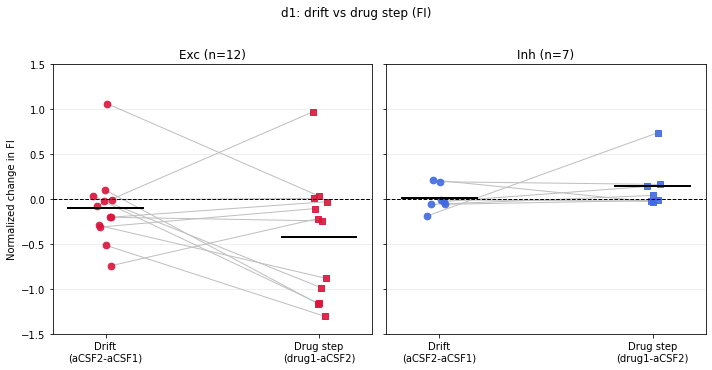

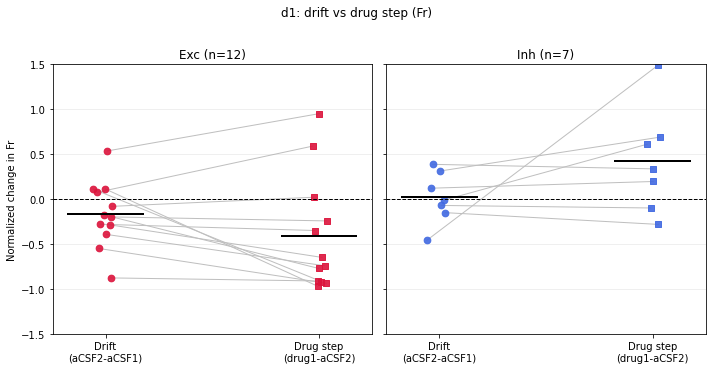

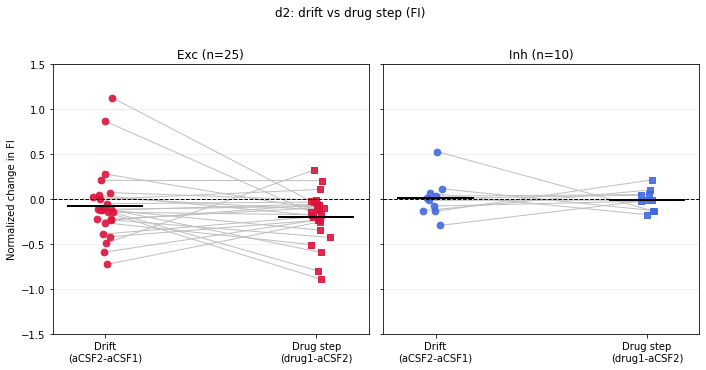

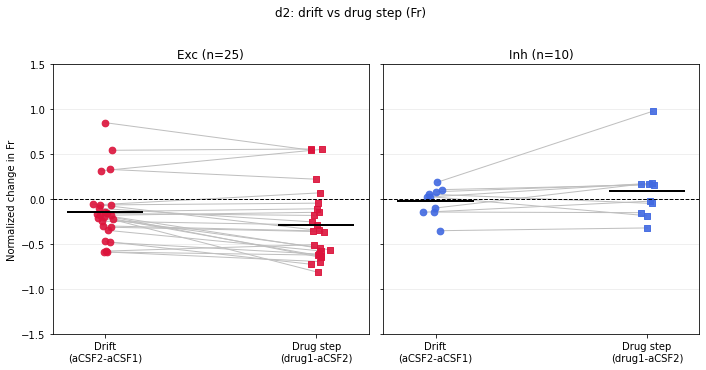

In [14]:

def paired_drift_plot(orig_df, receptor="d1", metric_label="FI", savepath=savepath,save=True):
    repeated_acsf = orig_df[orig_df.cond=='acsf']
    cond = receptor
    idx = np.where(np.unique(repeated_acsf.exp_name,return_counts=True)[1]>1)[0]
    names = np.unique(repeated_acsf.exp_name,return_counts=True)[0][idx]
    acsf_with_2_trials = list(set(np.array(repeated_acsf.exp_name)[idx]))
    repeated_acsf_filtered = repeated_acsf[repeated_acsf.exp_name.isin(names)]

    exps_with_repeated_acsf = repeated_acsf_filtered.exp_name.unique()
    drug_repeated = orig_df[orig_df.exp_name.isin(exps_with_repeated_acsf) ]
    drug_repeated_exps = drug_repeated[drug_repeated.cond==cond].exp_name.unique()
    drug_with_repeated_acsf = orig_df[orig_df.exp_name.isin(drug_repeated_exps)]

    exps,counts = np.unique(drug_with_repeated_acsf.exp_name,return_counts=True)
    delta_FI_repeated = []
    delta_FI_drug = []
    delta_fr_repeated = []
    delta_fr_drug = []

    ei = []

    for exp in exps:
        df = drug_with_repeated_acsf[drug_with_repeated_acsf.exp_name==exp]
        if np.array(df.ei_labels)[0] ==1.0:
            ei.append('Exc')
        else:
            ei.append('Inh')
        drug_idx = np.where(np.array(df.cond)==cond)[0][0]

        FI1 = df[df.trialnr == 0 ]['FI']
        FI2 = df[df.trialnr == 1 ]['FI']
        drug_data_FI = df[df.trialnr == drug_idx ]['FI']
        delta_FI_repeated.append((FI2.to_numpy()-FI1.to_numpy())/FI1.to_numpy())
        delta_FI_drug.append((drug_data_FI.to_numpy()-FI2.to_numpy())/FI2.to_numpy())

        Fr1 = df[df.trialnr == 0 ]['fr']
        Fr2 = df[df.trialnr == 1 ]['fr']
        drug_data_FR = df[df.trialnr == drug_idx ]['fr']

        delta_fr_repeated.append((Fr2.to_numpy()-Fr1.to_numpy())/Fr1.to_numpy())
        delta_fr_drug.append((drug_data_FR.to_numpy()-Fr1.to_numpy())/Fr1.to_numpy())


    data_frame  = pd.DataFrame({'$\Delta$f/f_repeated'   :np.float32(np.hstack(delta_fr_repeated)),
                                '$\Delta$FI/FI_repeated' :np.float32(np.hstack(delta_FI_repeated)),
                                '$\Delta$f/f_drug' :np.float32(np.hstack(delta_fr_drug)),
                                '$\Delta$FI/FI_drug' :np.float32(np.hstack(delta_FI_drug)),
                                'exp_name':np.hstack([np.repeat(exps[i],len(delta_fr_repeated[i])) for i in range(len(exps))]),
                                'color':ei})

    ylim = [-4,4]
    xlim = [-2,2]
    data_frame = data_frame[(data_frame['$\Delta$FI/FI_repeated']<=ylim[1]) & (data_frame['$\Delta$FI/FI_repeated']>ylim[0])]
    data_frame = data_frame[(data_frame['$\Delta$f/f_repeated']<=xlim[1]) & (data_frame['$\Delta$f/f_repeated']>xlim[0])]
    data_frame = data_frame[(data_frame['$\Delta$FI/FI_drug']<=ylim[1]) & (data_frame['$\Delta$FI/FI_drug']>ylim[0])]
    data_frame = data_frame[(data_frame['$\Delta$f/f_drug']<=xlim[1]) & (data_frame['$\Delta$f/f_drug']>xlim[0])]

    df = data_frame.copy()
    # sub = df[df["cond"] == receptor].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    colors = {"Exc": "crimson", "Inh": "royalblue"}

    for ax, cell_type in zip(axes, ["Exc", "Inh"]):
        d = df[df["color"] == cell_type].copy().reset_index(drop=True)

        if len(d) == 0:
            ax.set_title(f"{cell_type}: no data")
            continue

        x1, x2 = 0, 1

        rng = np.random.default_rng(42)
        jitter1 = rng.normal(0, 0.03, len(d))
        jitter2 = rng.normal(0, 0.03, len(d))
        if metric_label == "FI":
             y1 = "$\Delta$FI/FI_repeated"
             y2 = "$\Delta$FI/FI_drug"  
        else:
             y1 = "$\Delta$f/f_repeated"
             y2 = "$\Delta$f/f_drug"          
        for i, row in d.iterrows():
            ax.plot(
                [x1 + jitter1[i], x2 + jitter2[i]],
                [row[y1], row[y2]],
                color="0.75",
                linewidth=1,
                zorder=1
            )

        ax.scatter(
            np.full(len(d), x1) + jitter1,
            d[y1],
            color=colors[cell_type],
            s=45,
            alpha=0.9,
            label="drift",
            zorder=2
        )

        ax.scatter(
            np.full(len(d), x2) + jitter2,
            d[y2],
            color=colors[cell_type],
            s=45,
            alpha=0.9,
            marker="s",
            label="drug step",
            zorder=2
        )

        mean_drift = d[y1].mean()
        mean_drug = d[y2].mean()

        ax.hlines(mean_drift, x1 - 0.18, x1 + 0.18, color="black", linewidth=2)
        ax.hlines(mean_drug, x2 - 0.18, x2 + 0.18, color="black", linewidth=2)

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xticks([x1, x2])
        ax.set_xticklabels(["Drift\n(aCSF2-aCSF1)", "Drug step\n(drug1-aCSF2)"])
        ax.set_title(f"{cell_type} (n={len(d)})")
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle(f"{cond}: drift vs drug step ({metric_label})", y=1.02)
    axes[0].set_ylabel(f"Normalized change in {metric_label}")
    plt.tight_layout()
    plt.ylim(-1.5, 1.5)
    if save:
        plt.savefig(savepath+f'{cond}_paired_drift_{metric_label}.pdf', dpi=200)    
    plt.show()
    return data_frame


df_d1_fi = paired_drift_plot(ephys, receptor='d1', metric_label="FI",savepath=savepath,save=True)
df_d1_fr = paired_drift_plot(ephys, receptor='d1', metric_label="Fr",savepath=savepath,save=True)

df_d2_fi = paired_drift_plot(ephys, receptor='d2', metric_label="FI",savepath=savepath,save=True)
df_d2_fr = paired_drift_plot(ephys, receptor='d2', metric_label="Fr",savepath=savepath,save=True)

# paired_drift_plot(ephys, receptor='m1-ago', metric_label="FI")
# paired_drift_plot(ephys, receptor='m1-ago', metric_label="Fr")




In [15]:

print(stats.ttest_ind(df_d1_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d1_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d1_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d1_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)))

print(stats.ttest_ind(df_d1_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d1_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d1_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d1_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)))

Ttest_indResult(statistic=0.9457923685096716, pvalue=0.35055977590472276) 0.3152641228365572
Ttest_indResult(statistic=0.03166744467113357, pvalue=0.9749121792568748) 0.010555814890377855


In [16]:

print(stats.ttest_ind(df_d2_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d2_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d2_fi['$\Delta$FI/FI_repeated'].to_numpy(dtype=np.float32), df_d2_fi['$\Delta$FI/FI_drug'].to_numpy(dtype=np.float32)))

print(stats.ttest_ind(df_d2_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d2_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)),
      cohend(df_d2_fr['$\Delta$f/f_repeated'].to_numpy(dtype=np.float32), df_d2_fr['$\Delta$f/f_drug'].to_numpy(dtype=np.float32)))

Ttest_indResult(statistic=1.2514309910643648, pvalue=0.21506536098002105) 0.30351659760763333
Ttest_indResult(statistic=0.7337352297258475, pvalue=0.46563244511063284) 0.17795693255273579


In [242]:

def calculate_projection(ephys_object, sta,plot= False):
    '''calculates the projection of the spike triggered stimulus and random triggered stimulus on the STA. 
    Args:        
        ephys_object (EphysSet_niccolo): object containing all the e-phys data for a given cell and condition
        sta (numpy array): spike triggered average for the given cell and condition
        plot (bool, optional): whether to plot the distribution of projections. Defaults to False.  
        Returns:
            pd.DataFrame: DataFrame containing the projections for spike-triggered and random-triggered stimuli 
    '''

    windows = sliding_window_view(ephys_object.I, len(sta))   # shape: (T-L+1, L)
    spike_windows = windows[ephys_object.spikeindices - (len(sta) - 1)]
    spike_windows = spike_windows/np.linalg.norm(spike_windows)
    spike_rand = windows[np.random.randint(0,len(ephys_object.I),len(ephys_object.spikeindices)) - (len(sta) - 1)]
    spike_rand = spike_rand/np.linalg.norm(spike_rand)
    spike_triggered_projection = np.dot(spike_windows, sta/np.linalg.norm(sta))
    random_triggered_projection = np.dot(spike_rand, sta/np.linalg.norm(sta))
    df = pd.DataFrame({'Spike-triggered':np.hstack(spike_triggered_projection),
                        'Random-triggered':np.hstack(random_triggered_projection)})
    if plot:
        fig,ax = plt.subplots()
        sns.kdeplot(data = df['Spike-triggered'], fill=True, label='Spike-triggered',color='blue', ax=ax)
        sns.kdeplot(data = df['Random-triggered'], fill=True, label='Random-triggered',color='red', ax=ax)
        plt.legend()
    return df

def compute_sta_nonlinearity(path,compute_spikes=False):
    """returns a dictonary with all the ephys properties for each cell for the 
    condition provided along with the aCSF counterpart. 
    Exc and inhibitory cells are segregated.
    
    Args:
        cond (list): a list containing the condion to be analyzed
        experimenter (str, optional): if a specific experimenter needs to aanlyzed seperately. Defaults to None.

    Raises:
        ValueError:  'condition should be a list even if a single value is provided'

    Returns:
        dict: dictionary containing all e-phys features for each cell  
    """

    sta_all  = [] 
    files = os.listdir(path)
    for f in files:
        # try:
            data = loadmatInPy(path +f)
            exp = f[:-13]
            exp = return_name_date_exp_fn(exp)
            
            for trial,instance in enumerate(data):
                sta = []
                cond = instance['input_generation_settings']['condition']
                print(exp, trial, cond)
                ephys_obj = EphysSet_niccolo(data=instance,cond=cond,exp_name=exp,trialnr=trial,compute_spikes=compute_spikes)
                sta_ = list(ephys_obj.get_sta())
                df = calculate_projection(ephys_obj,sta_,plot=False)
                sta.append([df['Spike-triggered']])
                sta.append([df['Random-triggered']])
                sta.append(ephys_obj.cond)
                sta.append(ephys_obj.exp_name)
                sta.append(trial)
                sta_all.append(sta)
                del ephys_obj
                del sta_
                del df
        # except:
        #     print('problem with ',f[:-13])
    return sta_all

In [ ]:
from FN_ephys_features import *


In [238]:
path = "D:/Analyzed/NC_170821_aCSF_D1ago_E4_analyzed.mat"
f = 'NC_170821_aCSF_D1ago_E4_analyzed.mat'
data = loadmatInPy(path)
exp = f[:-13]
exp = return_name_date_exp_fn(exp)
sta_all  = []
spike_inds = []
for trial,instance in enumerate(data):
    sta = []
    cond = instance['input_generation_settings']['condition']
    print(exp, trial, cond)
    ephys_obj = EphysSet_niccolo(data=instance,cond=cond,exp_name=exp,trialnr=trial,compute_spikes=True)
    spike_inds.append(ephys_obj.spikeindices)
    sta = list(ephys_obj.get_sta())
    sta.append(ephys_obj.cond)
    sta.append(ephys_obj.exp_name)
    sta.append(trial)
    sta_all.append(sta)

170821_NC_D1ago 0 aCSF
170821_NC_D1ago 1 D1ago


In [ ]:
from numpy.lib.stride_tricks import sliding_window_view


In [243]:
all = compute_sta_nonlinearity(path="D:/Analyzed/", compute_spikes=True)

190718_asli_E2 0 ACSF
190718_asli_E2 1 M1-ago
190718_asli_E2 2 M1-ant
190711_asli_E1 0 ACSF
190711_asli_E1 1 M1-ago
190711_asli_E1 2 M1-ant
190711_asli_E2 0 ACSF
190711_asli_E2 1 M1-ago
190711_asli_E2 2 M1-ant
190712_asli_E2 0 ACSF
190712_asli_E2 1 M1-ago
190712_asli_E2 2 M1-ant
190712_asli_E3 0 ACSF
190712_asli_E3 1 M1-ago
190712_asli_E3 2 M1-ant
190715_asli_E3 0 ACSF
190715_asli_E3 1 M1-ago
190718_asli_E1 0 ACSF
190718_asli_E1 1 M1-ago
190718_asli_E1 2 M1-ant
190802_asli_E1 0 ACSF
190802_asli_E1 1 M1-ago
190802_asli_E1 2 M1-ago+ant
190802_asli_E2 0 ACSF
190802_asli_E2 1 M1-ago
190802_asli_E2 2 M1-ago+ant
190802_asli_E3 0 ACSF
190802_asli_E3 1 M1-ago
190802_asli_E3 2 M1-ago+ant
190723_asli_E2 0 ACSF
190723_asli_E2 1 M1-ago
190723_asli_E2 2 M1-ant
190723_asli_E3 0 ACSF
190723_asli_E3 1 M1-ago
190723_asli_E3 2 M1-ant
190723_asli_E5 0 ACSF
190723_asli_E5 1 M1-ago
190723_asli_E5 2 M1-ant
190724_asli_E4 0 ACSF
190724_asli_E4 1 M1-ago
190724_asli_E4 2 M1-ant
190724_asli_E5 0 ACSF
190724_asl

In [269]:
feats = ['spike_triggered',
        'random_triggered',
        'mean_spike_triggered',
        'mean_random_triggered',
        'auc_spike_triggered',
        'auc_random_triggered',
        'exp_name',
        'trialnr',
        'cond',]

df = pd.DataFrame(columns=feats)
for i in range(len(all)):
    df.loc[i,'spike_triggered'] = np.array(all)[i][0]
    df.loc[i,'mean_spike_triggered'] = np.mean(np.array(all)[i][0])
    df.loc[i,'random_triggered'] = np.array(all)[i][1]
    df.loc[i,'mean_random_triggered'] = np.mean(np.array(all)[i][1])
    df.loc[i,'auc_spike_triggered'] = np.trapz(np.sort(np.array(all)[i][0]))
    df.loc[i,'auc_random_triggered'] = np.trapz(np.sort(np.array(all)[i][1]))
    df.loc[i,feats[6:]]  = np.array(all)[i][2:]
df.to_pickle("G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/gain_features.pkl")

<ipython-input-269-1d06675f5f1b>:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  df.loc[i,'spike_triggered'] = np.array(all)[i][0]
<ipython-input-269-1d06675f5f1b>:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  df.loc[i,'spike_triggered'] = np.array(all)[i][0]
<ipython-input-269-1d06675f5f1b>:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating 

In [302]:
df.columns = ['spike_triggered', 'random_triggered', 'mean_spike_triggered',
       'mean_random_triggered', 'auc_spike_triggered', 'auc_random_triggered',
       'cond','trialnr','exp_name' ]

In [304]:
df.to_pickle("G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/gain_features.pkl")

In [306]:
pd.read_pickle("G:/My Drive/Data For Publication/paper2/PNAS_submission/Revision/gain_features.pkl")

,spike_triggered,random_triggered,mean_spike_triggered,mean_random_triggered,auc_spike_triggered,auc_random_triggered,cond,trialnr,exp_name
0,"[[0.0028013141035008408, 0.004591908802943468,...","[[0.0028716492898298073, -0.01194917888584203,...",0.004957,-0.003376,14.874376416683928,-10.131860200859007,acsf,190718_asli_E2,0
1,"[[0.0016608814244394791, 0.003968704938167891,...","[[-0.012165051804006843, -0.004973352637214132...",0.004716,-0.004164,12.899797056390124,-11.3931075089563,m1-ago,190718_asli_E2,1
2,"[[0.0010708493964201131, 0.0034102526589857803...","[[-0.011243464151740948, -0.014242467163477587...",0.003819,-0.004374,10.507638747653719,-12.032791121553519,m1-ant,190718_asli_E2,2
3,"[[0.046530085902267995, 0.05711275462769333, 0...","[[0.0038481305306841025, 0.0733606714631705, 0...",0.053401,0.016812,9.294494011187759,2.9344315678769965,acsf,190711_asli_E1,0
4,"[[0.0482023695746199, 0.0680687864084785, 0.05...","[[0.014212121534927808, 0.0682180307063186, 0....",0.058459,0.013616,8.120175983427195,1.885506907133589,m1-ago,190711_asli_E1,1
...,...,...,...,...,...,...,...,...,...
850,"[[-0.008018323448232783, -0.004764839515915881...","[[-0.009329184574377543, -0.012694891073744783...",-0.003403,-0.011448,-6.266250704047037,-21.07702122109283,cirazoline,190909_xuan_E3,1
851,"[[-0.010936504014925366, -0.004757711608689352...","[[-0.012122070776406299, -0.01962297430187302,...",-0.003166,-0.017578,-2.5262287291037797,-14.014802479511909,agoanta,190909_xuan_E3,2
852,"[[0.0022785618230702215, 0.005436823710082032,...","[[0.001758695123670277, -0.00438871683663174, ...",0.005801,-0.001147,24.148573858143994,-4.776217911210118,acsf,190909_xuan_E4,0
853,"[[-0.0003627207440641023, 0.003270533628665479...","[[-0.006849412925235781, -0.006449778557067063...",0.003406,-0.002354,18.694243367107184,-12.923976813652988,cirazoline,190909_xuan_E4,1


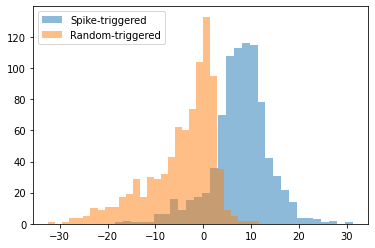

In [ ]:
plt.hist(df['auc_spike_triggered'], bins=30, alpha=0.5, label='Spike-triggered')
plt.hist(df['auc_random_triggered'], bins=30, alpha=0.5, label='Random-triggered')
plt.legend()

plt.hist(df['auc_spike_triggered'], bins=30, alpha=0.5, label='Spike-triggered')
plt.hist(df['auc_random_triggered'], bins=30, alpha=0.5, label='Random-triggered')
plt.legend()

In [153]:
cols_ephys = ['current_at_first_spike', 'ap_count', 'fr', 'inst_fr','time_to_first_spike',
             'mean_isi', 'median_isi', 'max_isi', 'min_isi',
             'first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',
             'mean_width', 'median_width', 'max_width', 'min_width',
             'mean_amplitude', 'median_amplitude', 'min_amplitude']

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs



def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


adj_rand_score_exc = {}
adj_MI_exc = {}
save_dtype = 'ephys'
ei_type = 'exc'
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

for cond in ['d1','d2','m1-ago']:
    print(cond)
    df_temp_acsf,df_temp_drug  = return_acsf_and_drug(ephys,cond=[cond],joint=False)
    df_temp_acsf_exc = df_temp_acsf[df_temp_acsf.ei_labels==0]
    df_temp_acsf_exc = df_temp_acsf_exc.drop_duplicates('exp_name')
    df_temp_drug_exc = df_temp_drug[df_temp_drug.ei_labels==0]
    df_temp_drug_exc = df_temp_drug_exc.drop_duplicates('exp_name')


    print(len(df_temp_acsf_exc), len(df_temp_drug_exc))

    clustering_acsf = AgglomerativeClustering(n_clusters=3)
    labels_acsf = clustering_acsf.fit_predict(df_temp_acsf_exc[cols_ephys])


    clustering_drug = AgglomerativeClustering(n_clusters=3)
    labels_drug = clustering_drug.fit_predict(df_temp_drug_exc[cols_ephys])

   
    adj_rand_score_exc[cond] = adjusted_rand_score(labels_acsf,labels_drug)
    adj_MI_exc[cond] =  adjusted_mutual_info_score(labels_drug,labels_acsf)





d1
29 29
d2
19 19
m1-ago
22 22


In [159]:
adj_MI_exc

{'d1': 0.4554749195081135,
 'd2': -0.06632036103957598,
 'm1-ago': 0.5230732120706326}